In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
fandango = pd.read_csv('fandango_scrape.csv')
fandango.head(5)

,FILM,STARS,RATING,VOTES
0,Fifty Shades of Grey (2015),4.0,3.9,34846
1,Jurassic World (2015),4.5,4.5,34390
2,American Sniper (2015),5.0,4.8,34085
3,Furious 7 (2015),5.0,4.8,33538
4,Inside Out (2015),4.5,4.5,15749


In [5]:
fandango.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FILM    504 non-null    object 
 1   STARS   504 non-null    float64
 2   RATING  504 non-null    float64
 3   VOTES   504 non-null    int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 15.9+ KB


In [7]:
fandango.describe()

,STARS,RATING,VOTES
count,504.000000,504.000000,504.000000
mean,3.558532,3.375794,1147.863095
std,1.563133,1.491223,3830.583136
min,0.000000,0.000000,0.000000
25%,3.500000,3.100000,3.000000
50%,4.000000,3.800000,18.500000
75%,4.500000,4.300000,189.750000
max,5.000000,5.000000,34846.000000


<Axes: xlabel='RATING', ylabel='VOTES'>

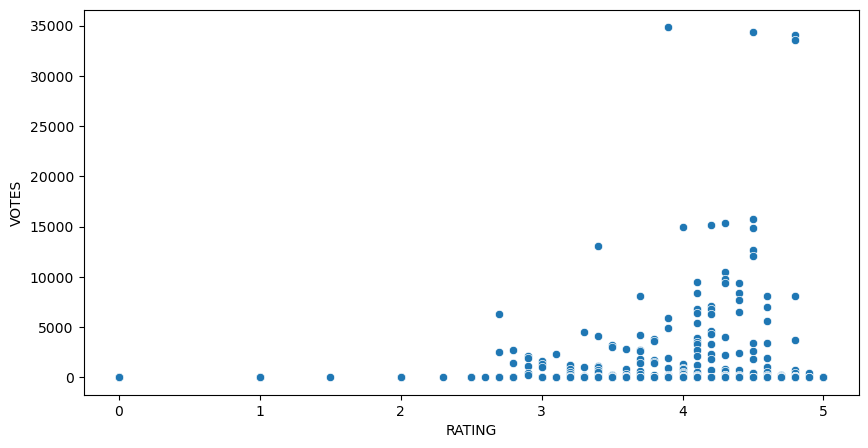

In [15]:
plt.figure(figsize=(10,5), dpi=100)
sns.scatterplot(data=fandango, y='VOTES', x='RATING')

In [22]:
fandango_numeric = fandango.select_dtypes(include=['float64', 'int64'])
correlation_fandango = fandango_numeric.corr()
correlation_fandango

,STARS,RATING,VOTES
STARS,1.000000,0.994696,0.164218
RATING,0.994696,1.000000,0.163764
VOTES,0.164218,0.163764,1.000000


In [23]:
title = 'Nom du titre du film (Annee)'

In [27]:
title.split('(')[-1].replace(')', '')

'Annee'

In [29]:
fandango['YEAR'] = fandango['FILM'].apply(lambda title: title.split('(')[-1].replace(')', ''))
fandango

,FILM,STARS,RATING,VOTES,YEAR
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015
1,Jurassic World (2015),4.5,4.5,34390,2015
2,American Sniper (2015),5.0,4.8,34085,2015
3,Furious 7 (2015),5.0,4.8,33538,2015
4,Inside Out (2015),4.5,4.5,15749,2015
...,...,...,...,...,...
499,Valiyavan (2015),0.0,0.0,0,2015
500,WWE SummerSlam 2015 (2015),0.0,0.0,0,2015
501,Yagavarayinum Naa Kaakka (2015),0.0,0.0,0,2015
502,"Yesterday, Today and Tomorrow (1964)",0.0,0.0,0,1964


In [30]:
fandango['YEAR'].value_counts()

YEAR
2015    478
2014     23
2016      1
1964      1
2012      1
Name: count, dtype: int64

<Axes: xlabel='YEAR', ylabel='count'>

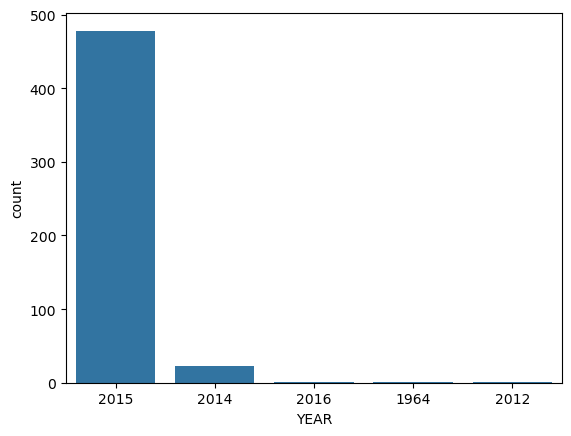

In [31]:
sns.countplot(data = fandango , x = 'YEAR')

In [32]:
fandango.nlargest(10, 'VOTES')

,FILM,STARS,RATING,VOTES,YEAR
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015
1,Jurassic World (2015),4.5,4.5,34390,2015
2,American Sniper (2015),5.0,4.8,34085,2015
3,Furious 7 (2015),5.0,4.8,33538,2015
4,Inside Out (2015),4.5,4.5,15749,2015
5,The Hobbit: The Battle of the Five Armies (2014),4.5,4.3,15337,2014
6,Kingsman: The Secret Service (2015),4.5,4.2,15205,2015
7,Minions (2015),4.0,4.0,14998,2015
8,Avengers: Age of Ultron (2015),5.0,4.5,14846,2015
9,Into the Woods (2014),3.5,3.4,13055,2014


In [34]:
no_vote = fandango['VOTES'] == 0
no_vote.sum()

69

In [36]:
fandango[fandango['VOTES'] == 0]

,FILM,STARS,RATING,VOTES,YEAR
435,6 Years (2015),0.0,0.0,0,2015
436,7 Minutes (2015),0.0,0.0,0,2015
437,A Year in Champagne (2015),0.0,0.0,0,2015
438,Balls Out (2015),0.0,0.0,0,2015
439,Before I Wake (2015),0.0,0.0,0,2015
...,...,...,...,...,...
499,Valiyavan (2015),0.0,0.0,0,2015
500,WWE SummerSlam 2015 (2015),0.0,0.0,0,2015
501,Yagavarayinum Naa Kaakka (2015),0.0,0.0,0,2015
502,"Yesterday, Today and Tomorrow (1964)",0.0,0.0,0,1964


In [37]:
fan_view = fandango[fandango['VOTES'] > 0]
fan_view

,FILM,STARS,RATING,VOTES,YEAR
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015
1,Jurassic World (2015),4.5,4.5,34390,2015
2,American Sniper (2015),5.0,4.8,34085,2015
3,Furious 7 (2015),5.0,4.8,33538,2015
4,Inside Out (2015),4.5,4.5,15749,2015
...,...,...,...,...,...
430,That Sugar Film (2015),5.0,5.0,1,2015
431,The Intern (2015),5.0,5.0,1,2015
432,The Park Bench (2015),5.0,5.0,1,2015
433,The Wanted 18 (2015),5.0,5.0,1,2015


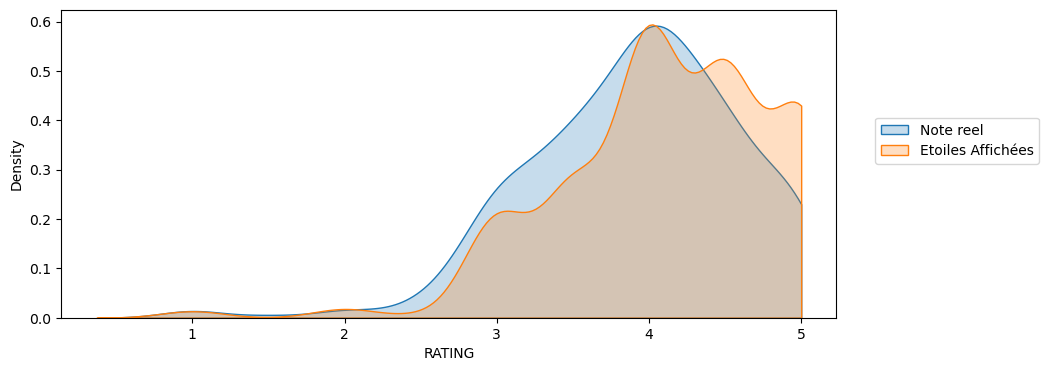

In [52]:
plt.figure(figsize=(10,4), dpi=100)
sns.kdeplot(data=fan_view, x='RATING', clip=[0,5], fill=True, label = 'Note reel')
sns.kdeplot(data=fan_view, x='STARS', clip=[0,5], fill=True, label = 'Etoiles Affichées')

plt.legend(loc= (1.05, 0.5))

In [55]:
fan_view['STARS_DIFF'] = fan_view['STARS'] - fan_view['RATING']
fan_view['STARS_DIFF'] = fan_view['STARS_DIFF'].round(2)

C:\Users\cocog\AppData\Local\Temp\ipykernel_16328\3824878028.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fan_view['STARS_DIFF'] = fan_view['STARS'] - fan_view['RATING']
C:\Users\cocog\AppData\Local\Temp\ipykernel_16328\3824878028.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fan_view['STARS_DIFF'] = fan_view['STARS_DIFF'].round(2)


In [56]:
fan_view

,FILM,STARS,RATING,VOTES,YEAR,STARS_DIFF
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015,0.1
1,Jurassic World (2015),4.5,4.5,34390,2015,0.0
2,American Sniper (2015),5.0,4.8,34085,2015,0.2
3,Furious 7 (2015),5.0,4.8,33538,2015,0.2
4,Inside Out (2015),4.5,4.5,15749,2015,0.0
...,...,...,...,...,...,...
430,That Sugar Film (2015),5.0,5.0,1,2015,0.0
431,The Intern (2015),5.0,5.0,1,2015,0.0
432,The Park Bench (2015),5.0,5.0,1,2015,0.0
433,The Wanted 18 (2015),5.0,5.0,1,2015,0.0


C:\Users\cocog\AppData\Local\Temp\ipykernel_16328\2929119187.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= fan_view, x='STARS_DIFF', palette='magma')


<Axes: xlabel='STARS_DIFF', ylabel='count'>

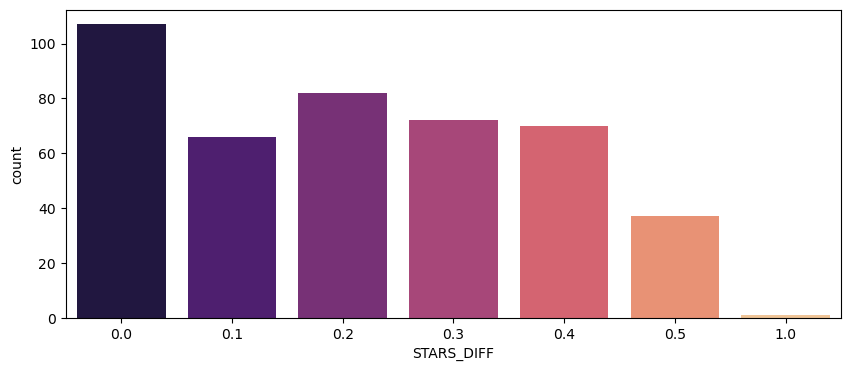

In [58]:
plt.figure(figsize=(10,4))
sns.countplot(data= fan_view, x='STARS_DIFF', palette='magma')

In [88]:
fan_view[fan_view['STARS_DIFF'] == 1]

,FILM,STARS,RATING,VOTES,YEAR,STARS_DIFF
381,Turbo Kid (2015),5.0,4.0,2,2015,1.0


## Partie 2

In [61]:
all_sites = pd.read_csv('all_sites_scores.csv')
all_sites.head(10)

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count
0,Avengers: Age of Ultron (2015),74,86,66,7.1,7.8,1330,271107
1,Cinderella (2015),85,80,67,7.5,7.1,249,65709
2,Ant-Man (2015),80,90,64,8.1,7.8,627,103660
3,Do You Believe? (2015),18,84,22,4.7,5.4,31,3136
4,Hot Tub Time Machine 2 (2015),14,28,29,3.4,5.1,88,19560
5,The Water Diviner (2015),63,62,50,6.8,7.2,34,39373
6,Irrational Man (2015),42,53,53,7.6,6.9,17,2680
7,Top Five (2014),86,64,81,6.8,6.5,124,16876
8,Shaun the Sheep Movie (2015),99,82,81,8.8,7.4,62,12227
9,Love & Mercy (2015),89,87,80,8.5,7.8,54,5367


In [62]:
all_sites.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FILM                        146 non-null    object 
 1   RottenTomatoes              146 non-null    int64  
 2   RottenTomatoes_User         146 non-null    int64  
 3   Metacritic                  146 non-null    int64  
 4   Metacritic_User             146 non-null    float64
 5   IMDB                        146 non-null    float64
 6   Metacritic_user_vote_count  146 non-null    int64  
 7   IMDB_user_vote_count        146 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 9.3+ KB


In [63]:
all_sites.describe()

,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,60.849315,63.876712,58.808219,6.519178,6.736986,185.705479,42846.205479
std,30.168799,20.024430,19.517389,1.510712,0.958736,316.606515,67406.509171
min,5.000000,20.000000,13.000000,2.400000,4.000000,4.000000,243.000000
25%,31.250000,50.000000,43.500000,5.700000,6.300000,33.250000,5627.000000
50%,63.500000,66.500000,59.000000,6.850000,6.900000,72.500000,19103.000000
75%,89.000000,81.000000,75.000000,7.500000,7.400000,168.500000,45185.750000
max,100.000000,94.000000,94.000000,9.600000,8.600000,2375.000000,334164.000000


(0.0, 100.0)

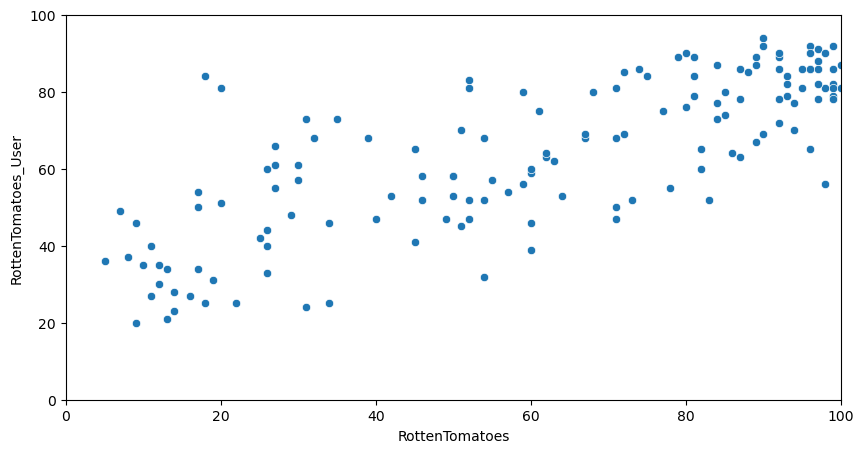

In [66]:
plt.figure(figsize=(10,5))
sns.scatterplot(data = all_sites, x='RottenTomatoes', y='RottenTomatoes_User' )
plt.ylim(0,100)
plt.xlim(0,100)

In [67]:
all_sites['Rotten_Diff'] = all_sites['RottenTomatoes'] - all_sites['RottenTomatoes_User']

In [68]:
all_sites['Rotten_Diff'].apply(abs).mean()

15.095890410958905

<Axes: xlabel='Rotten_Diff', ylabel='Count'>

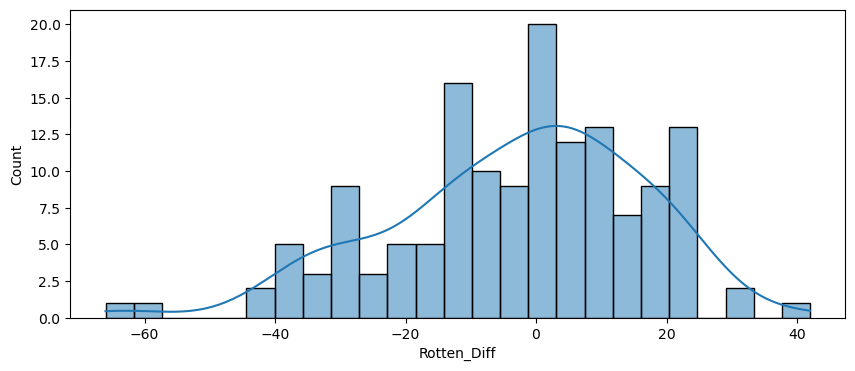

In [70]:
#On trace la difference  entre les notes critiques RT et la note utilisateurs RT
plt.figure(figsize=(10,4))
sns.histplot(data = all_sites, x='Rotten_Diff', kde = True, bins=25)

<Axes: xlabel='Rotten_Diff', ylabel='Count'>

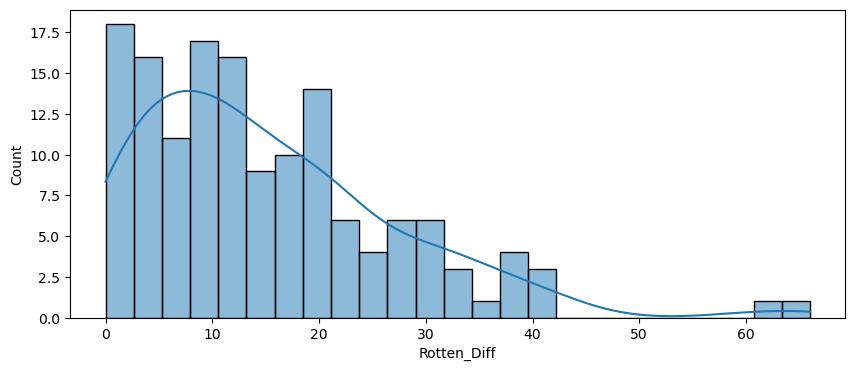

In [71]:
plt.figure(figsize=(10,4))
sns.histplot(x=all_sites['Rotten_Diff'].apply(abs), kde = True, bins=25)

In [78]:
#Top 5 des films que les utilisateurs ont plus aimé que les critiques

all_sites.nsmallest(5, 'Rotten_Diff')[['FILM', 'Rotten_Diff']]

,FILM,Rotten_Diff
3,Do You Believe? (2015),-66
85,Little Boy (2015),-61
105,Hitman: Agent 47 (2015),-42
134,The Longest Ride (2015),-42
125,The Wedding Ringer (2015),-39


In [79]:
all_sites.nlargest(5, 'Rotten_Diff')[['FILM', 'Rotten_Diff']]

,FILM,Rotten_Diff
69,Mr. Turner (2014),42
112,It Follows (2015),31
115,While We're Young (2015),31
37,Welcome to Me (2015),24
40,I'll See You In My Dreams (2015),24


(0.0, 100.0)

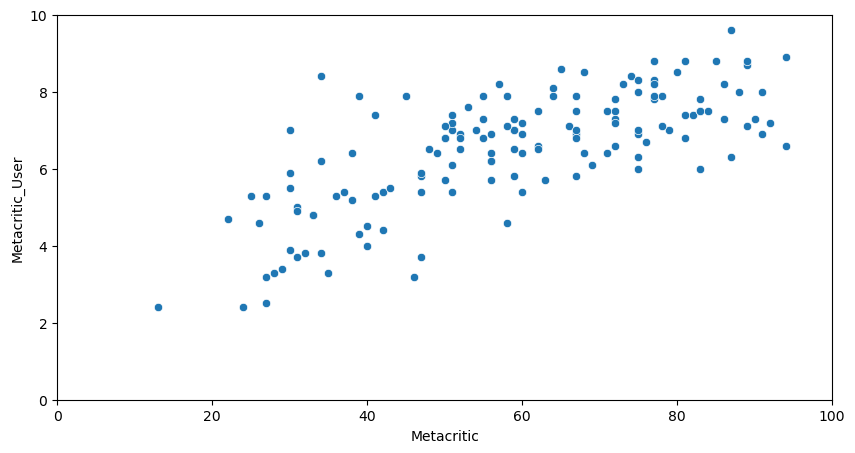

In [81]:
plt.figure(figsize=(10,5))
sns.scatterplot(data = all_sites, x='Metacritic', y='Metacritic_User' )
plt.ylim(0,10)
plt.xlim(0,100)

<Axes: xlabel='Metacritic_user_vote_count', ylabel='IMDB_user_vote_count'>

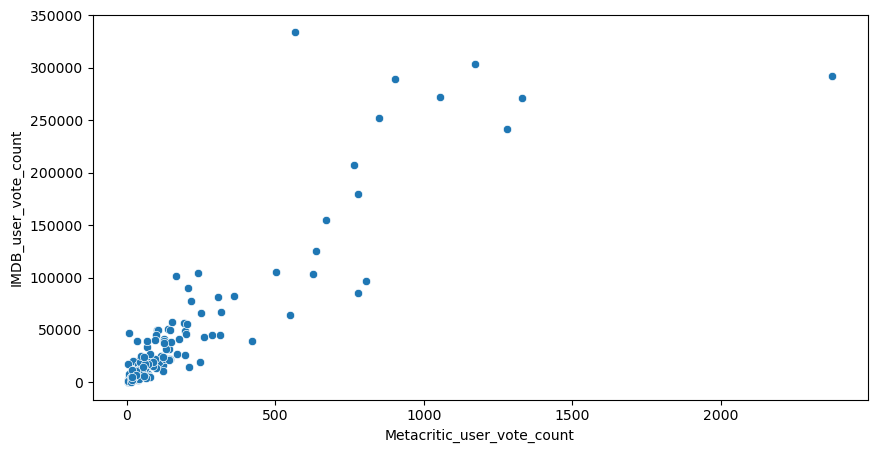

In [84]:
# Relation au nombre de vote entre metacritic et IMDB

plt.figure(figsize=(10,5))
sns.scatterplot(data = all_sites, x='Metacritic_user_vote_count', y='IMDB_user_vote_count' )


In [86]:
#la valeur abberante dans leurs relaton 

all_sites.nlargest(1, 'IMDB_user_vote_count')

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff
14,The Imitation Game (2014),90,92,73,8.2,8.1,566,334164,-2


In [87]:
all_sites.nlargest(1, 'Metacritic_user_vote_count')

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff
88,Mad Max: Fury Road (2015),97,88,89,8.7,8.3,2375,292023,9


## Partie 3

## On Combine les dataFrame Fandago avec All_sites on vas juste choisir le films qsui sont dans le 2 table 

In [89]:
#on verifie toujours que le 2 film dans Fandago et All site portent le meme nom

df = pd.merge(fandango, all_sites, on = 'FILM', how='inner')

In [90]:
df

,FILM,STARS,RATING,VOTES,YEAR,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015,25,42,46,3.2,4.2,778,179506,-17
1,Jurassic World (2015),4.5,4.5,34390,2015,71,81,59,7.0,7.3,1281,241807,-10
2,American Sniper (2015),5.0,4.8,34085,2015,72,85,72,6.6,7.4,850,251856,-13
3,Furious 7 (2015),5.0,4.8,33538,2015,81,84,67,6.8,7.4,764,207211,-3
4,Inside Out (2015),4.5,4.5,15749,2015,98,90,94,8.9,8.6,807,96252,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,"Kumiko, The Treasure Hunter (2015)",3.5,3.5,41,2015,87,63,68,6.4,6.7,19,5289,24
141,The Diary of a Teenage Girl (2015),4.0,3.6,38,2015,95,81,87,6.3,7.0,18,1107,14
142,The Wrecking Crew (2015),4.5,4.2,38,2015,93,84,67,7.0,7.8,4,732,9
143,Tangerine (2015),4.0,3.9,36,2015,95,86,86,7.3,7.4,14,696,9


# on normalise les colones

In [92]:
df.describe().transpose()['max']

STARS                              5.0
RATING                             4.8
VOTES                          34846.0
RottenTomatoes                   100.0
RottenTomatoes_User               94.0
Metacritic                        94.0
Metacritic_User                    9.6
IMDB                               8.6
Metacritic_user_vote_count      2375.0
IMDB_user_vote_count          334164.0
Rotten_Diff                       42.0
Name: max, dtype: float64

In [93]:
df['RT_norm'] = np.round(df['RottenTomatoes']/20, 1)
df['RTU_norm'] = np.round(df['RottenTomatoes_User']/20, 1)
df['Meta_norm'] = np.round(df['Metacritic']/20, 1)
df['MetaU_norm'] = np.round(df['Metacritic_User']/2, 1)
df['IMDB_norm'] = np.round(df['IMDB']/2, 1)

In [94]:
df.head()

,FILM,STARS,RATING,VOTES,YEAR,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff,RT_norm,RTU_norm,Meta_norm,MetaU_norm,IMDB_norm
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015,25,42,46,3.2,4.2,778,179506,-17,1.2,2.1,2.3,1.6,2.1
1,Jurassic World (2015),4.5,4.5,34390,2015,71,81,59,7.0,7.3,1281,241807,-10,3.6,4.0,3.0,3.5,3.6
2,American Sniper (2015),5.0,4.8,34085,2015,72,85,72,6.6,7.4,850,251856,-13,3.6,4.2,3.6,3.3,3.7
3,Furious 7 (2015),5.0,4.8,33538,2015,81,84,67,6.8,7.4,764,207211,-3,4.0,4.2,3.4,3.4,3.7
4,Inside Out (2015),4.5,4.5,15749,2015,98,90,94,8.9,8.6,807,96252,8,4.9,4.5,4.7,4.4,4.3


In [95]:
df.columns

Index(['FILM', 'STARS', 'RATING', 'VOTES', 'YEAR', 'RottenTomatoes',
       'RottenTomatoes_User', 'Metacritic', 'Metacritic_User', 'IMDB',
       'Metacritic_user_vote_count', 'IMDB_user_vote_count', 'Rotten_Diff',
       'RT_norm', 'RTU_norm', 'Meta_norm', 'MetaU_norm', 'IMDB_norm'],
      dtype='object')

In [96]:
norm_score = df[[ 'STARS', 'RATING','RT_norm', 'RTU_norm', 'Meta_norm', 'MetaU_norm', 'IMDB_norm']]

In [97]:
norm_score

,STARS,RATING,RT_norm,RTU_norm,Meta_norm,MetaU_norm,IMDB_norm
0,4.0,3.9,1.2,2.1,2.3,1.6,2.1
1,4.5,4.5,3.6,4.0,3.0,3.5,3.6
2,5.0,4.8,3.6,4.2,3.6,3.3,3.7
3,5.0,4.8,4.0,4.2,3.4,3.4,3.7
4,4.5,4.5,4.9,4.5,4.7,4.4,4.3
...,...,...,...,...,...,...,...
140,3.5,3.5,4.4,3.2,3.4,3.2,3.4
141,4.0,3.6,4.8,4.0,4.4,3.2,3.5
142,4.5,4.2,4.6,4.2,3.4,3.5,3.9
143,4.0,3.9,4.8,4.3,4.3,3.6,3.7


<Axes: ylabel='Density'>

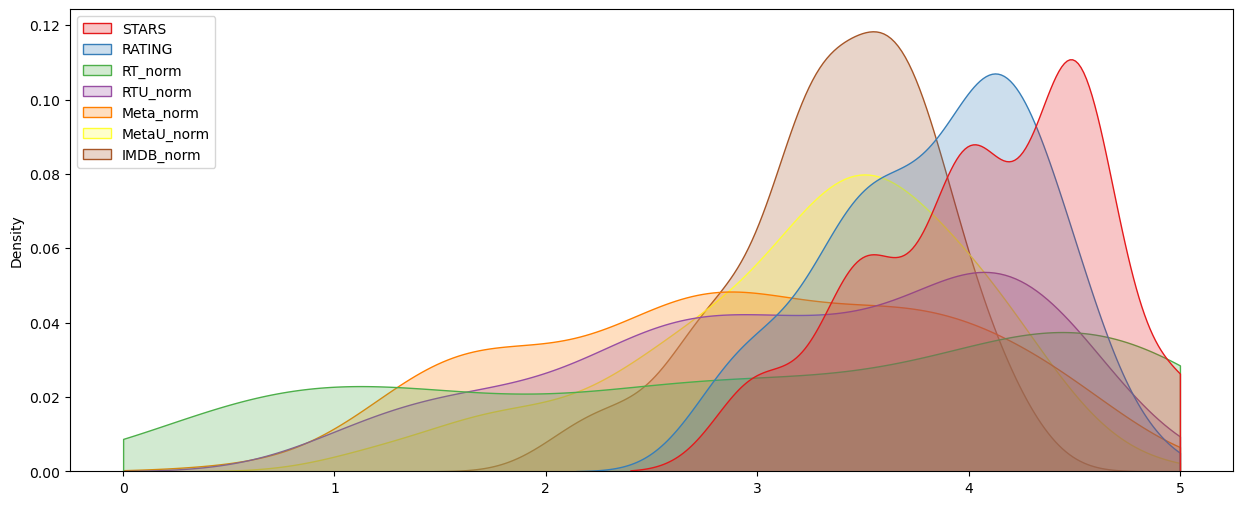

In [120]:
#On compare maintenant 

plt.figure(figsize=(15,6))
sns.kdeplot(data = norm_score, clip=[0,5], fill = True, palette='Set1')

<Axes: ylabel='Density'>

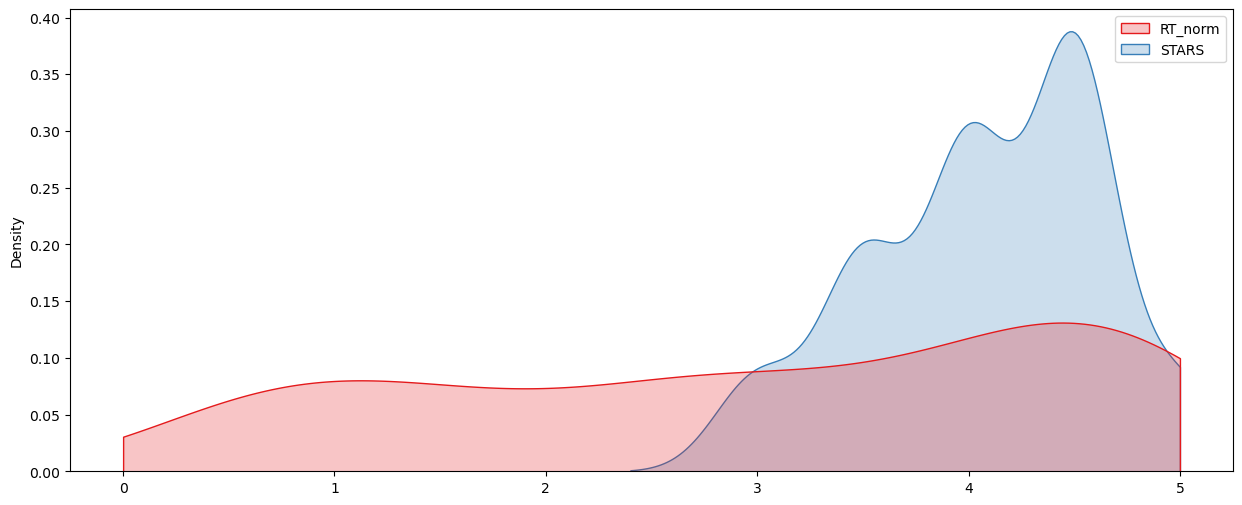

In [118]:
# La difference avec chacun

plt.figure(figsize=(15,6))
sns.kdeplot(data = norm_score[['RT_norm', 'STARS']] , clip=[0,5], fill = True, palette='Set1')

## on cree un histogramee

<Axes: ylabel='Count'>

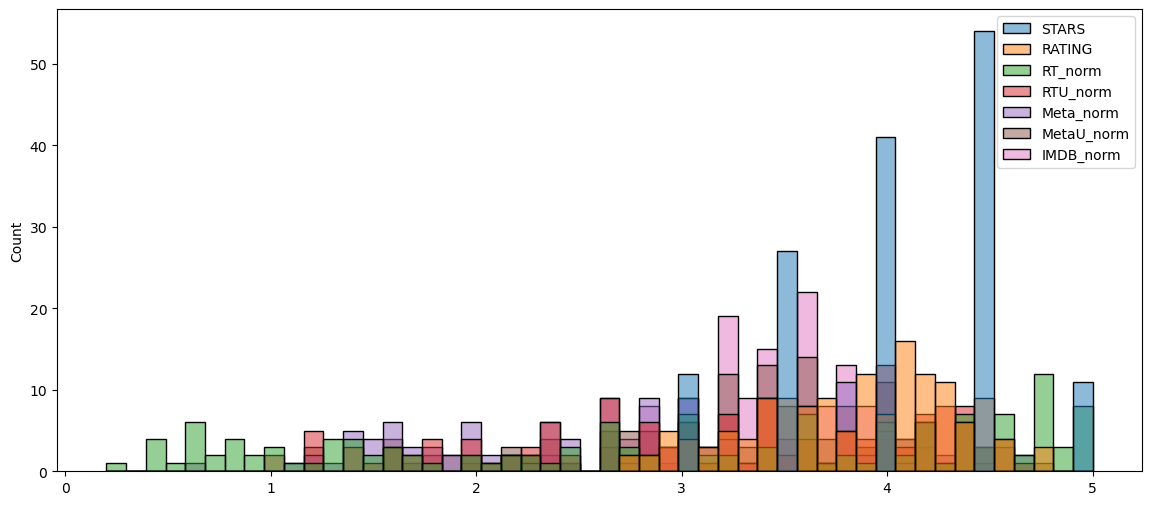

In [107]:
plt.figure(figsize=(14,6))
sns.histplot(norm_score, bins=50)

### On trace une clustermap

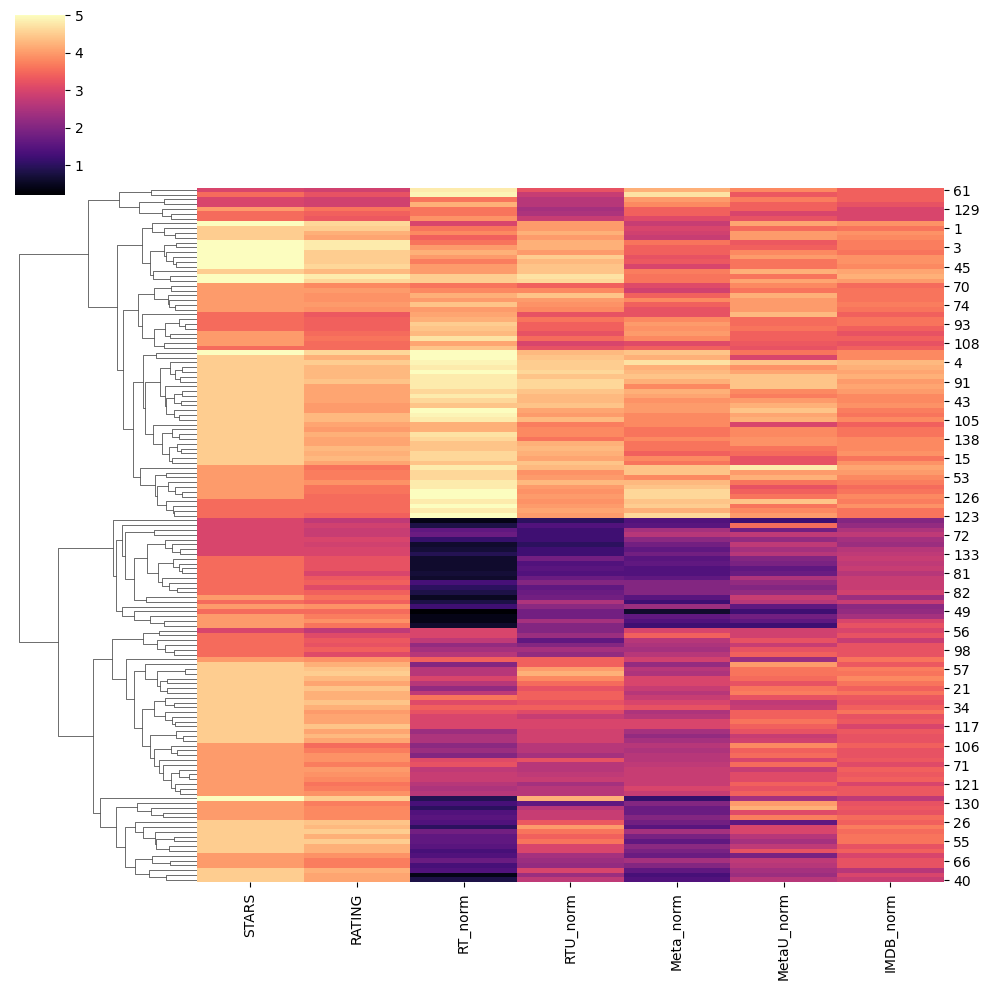

In [110]:
sns.clustermap(norm_score, cmap='magma', col_cluster= False )

### On veut extraire les pires les films et voir leurs note

In [109]:
norm_score.columns

Index(['STARS', 'RATING', 'RT_norm', 'RTU_norm', 'Meta_norm', 'MetaU_norm',
       'IMDB_norm'],
      dtype='object')

In [111]:
norm_films = df[['FILM','STARS', 'RATING', 'RT_norm', 'RTU_norm', 'Meta_norm', 'MetaU_norm',
       'IMDB_norm']]

In [115]:
#Les 10 pire films selon RottenTomatos vu qu'ils sont les plus severe

worst_film = norm_films.nsmallest(10,'RT_norm')
worst_film

,FILM,STARS,RATING,RT_norm,RTU_norm,Meta_norm,MetaU_norm,IMDB_norm
49,Paul Blart: Mall Cop 2 (2015),3.5,3.5,0.2,1.8,0.6,1.2,2.2
25,Taken 3 (2015),4.5,4.1,0.4,2.3,1.3,2.3,3.0
28,Fantastic Four (2015),3.0,2.7,0.4,1.0,1.4,1.2,2.0
54,Hot Pursuit (2015),4.0,3.7,0.4,1.8,1.6,1.8,2.4
84,Hitman: Agent 47 (2015),4.0,3.9,0.4,2.4,1.4,1.6,3.0
50,The Boy Next Door (2015),4.0,3.6,0.5,1.8,1.5,2.8,2.3
77,Seventh Son (2015),3.5,3.2,0.6,1.8,1.5,2.0,2.8
78,Mortdecai (2015),3.5,3.2,0.6,1.5,1.4,1.6,2.8
83,Sinister 2 (2015),3.5,3.3,0.6,1.7,1.6,2.5,2.8
87,Unfinished Business (2015),3.5,3.2,0.6,1.4,1.6,1.9,2.7


<Axes: ylabel='Density'>

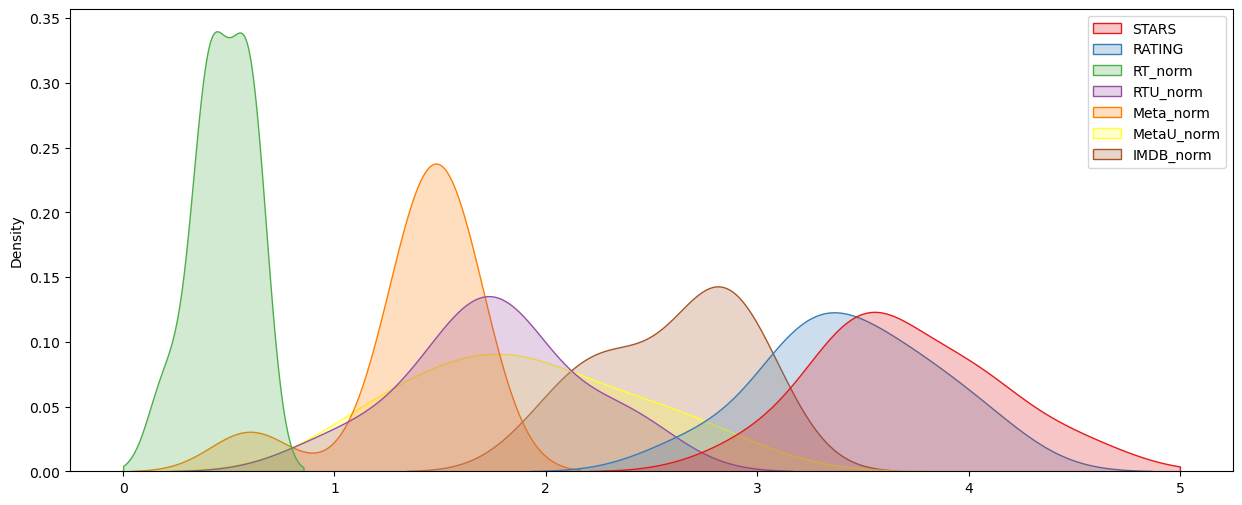

In [117]:
plt.figure(figsize=(15,6))
sns.kdeplot(data = worst_film, clip=[0,5], fill = True, palette='Set1')

## On affiche les resultats de l'une des plus grandes escroqueri qui est Taken 3

In [126]:
worst_film[worst_film['FILM'] == 'Taken 3 (2015)'].describe().transpose()['max']

STARS         4.5
RATING        4.1
RT_norm       0.4
RTU_norm      2.3
Meta_norm     1.3
MetaU_norm    2.3
IMDB_norm     3.0
Name: max, dtype: float64

## On calcule sa moyenne et voir l'ecart avec Fandango

In [127]:
3 + 2.3 + 1.3 + 2.3 + 0.4

9.299999999999999

In [128]:
9.3/5

1.86

### en moyenne 1.86 dans les autres sites alors que Fandango lui met la note de 4.1 ahhhhhhhh abus

# Bon on s'arrete la Fin